In [3]:
# =============================================================================
# APARTMENT PRICE PREDICTION — COMPANY X
# Graduation Project | Business Intelligence
# =============================================================================

# -----------------------------------------------------------------------------
# SECTION 1 | IMPORT LIBRARIES
# -----------------------------------------------------------------------------
# pandas   → load and manipulate data (tables, columns, rows)
# numpy    → mathematical operations and arrays
import pandas as pd
import numpy as np

# matplotlib & seaborn → create charts and visualizations
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# sklearn → everything related to machine learning
# - train_test_split  : split data into training and testing sets
# - cross_val_score   : evaluate model reliability
# - KFold             : split data into K equal parts for validation
from sklearn.model_selection import train_test_split, cross_val_score, KFold

# - LabelEncoder  : convert text categories (city names) into numbers
# - StandardScaler: normalize numbers to the same scale
from sklearn.preprocessing import LabelEncoder, StandardScaler

# regression models we will train and compare
# - LinearRegression  : simple straight-line prediction
# - Ridge & Lasso     : linear models with penalty to avoid overfitting
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# - DecisionTreeRegressor  : predicts using a tree of if/else rules
# - RandomForestRegressor  : many trees combined → more accurate
# - GradientBoostingRegressor : builds trees one by one, each fixing the last
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# metrics to measure how good our predictions are
# - mean_absolute_error: average difference between predicted and actual price
# - mean_squared_error : penalizes large errors more heavily
# - r2_score : how much of the price variation the model explains
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# joblib → save and load the trained model
import joblib

# suppress unnecessary warning messages
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
#Verifying
print("All libraries imported ")


All libraries imported 


In [5]:
# -----------------------------------------------------------------------------
# SECTION 2 | LOAD DATA
# -----------------------------------------------------------------------------

# read the Excel file into a DataFrame (like a table in Python)
df = pd.read_excel('/content/company X.xlsx')

# -----------------------------------------------------------------------------

print(" DATASET OVERVIEW")


# show total number of apartments and features
print(f"  Total apartments : {df.shape[0]}")
print(f"  Total features   : {df.shape[1]}")

 DATASET OVERVIEW
  Total apartments : 603
  Total features   : 22


In [6]:
# -----------------------------------------------------------------------------
# SECTION 3 | CLEAN DATA
# -----------------------------------------------------------------------------

# remove rows where price is missing — we can't train without a target value
df = df.dropna(subset=['price'])

# remove apartments with price less than 1000 — these are clearly data errors
df = df[df['price'] > 1000].copy()

# -----------------------------------------------------------------------------
# fix inconsistent text in city and location columns
# example: 'amman' and 'Amman' are the same city — we unify them
# .str.strip() → removes extra spaces
# .str.title() → makes First Letter Capital
df['city']     = df['city'].str.strip().str.title()
df['location'] = df['location'].str.strip().str.title()

# -----------------------------------------------------------------------------
# fix furnishing level — should be between 0 and 5 only
# .clip(0, 5) → any value above 5 becomes 5, any below 0 becomes 0
df['furnishing_level(1-5)'] = df['furnishing_level(1-5)'].clip(0, 5)

# -----------------------------------------------------------------------------

print(" DATA CLEANING SUMMARY")
print(f"  Clean apartments : {len(df)}")
print(f"  Missing values   : {df.isnull().sum().sum()}")
print(f"  Cities found     : {sorted(df['city'].unique().tolist())}")


 DATA CLEANING SUMMARY
  Clean apartments : 603
  Missing values   : 0
  Cities found     : ['Ajloun', 'Amman', 'Aqaba', 'Irbid', 'Karak', 'Madaba', 'Salat', 'Salt', 'Zarqa']


In [7]:
# -----------------------------------------------------------------------------
# SECTION 4 | FIX CITY NAMES
# -----------------------------------------------------------------------------

# 'Salat' and 'Salt' are the same city written differently — we unify them
# .replace() → finds the wrong name and replaces it with the correct one
df['city'] = df['city'].replace('Salat', 'Salt')

# -----------------------------------------------------------------------------

print(" CITY NAMES FIXED")
print(f"  Cities now: {sorted(df['city'].unique().tolist())}")
print(f"  Total cities: {df['city'].nunique()}")


 CITY NAMES FIXED
  Cities now: ['Ajloun', 'Amman', 'Aqaba', 'Irbid', 'Karak', 'Madaba', 'Salt', 'Zarqa']
  Total cities: 8


In [8]:
# -----------------------------------------------------------------------------
# SECTION 5 | FEATURE ENGINEERING
# -----------------------------------------------------------------------------
# here we create NEW columns from existing ones
# this gives the model more useful information to learn from

# -----------------------------------------------------------------------------
# floor number — the original floor column uses a coded format
# example: -101 means basement, 101 means floor 1, 201 means floor 2
# we extract just the floor number as a simple integer
def decode_floor(val):
    if pd.isna(val):
        return 0
    val = int(val)
    if val < 0:
        return 0                    # basement = floor 0
    return int(str(abs(val))[0])    # first digit = floor number

df['floor_number'] = df['floor'].apply(decode_floor)

# is_basement — binary flag: 1 if apartment is in basement, 0 if not
# basement apartments usually sell for less — this helps the model know that
df['is_basement'] = (df['floor_number'] == 0).astype(int)

# total_rooms — sum of all rooms in the apartment
# bigger apartments with more rooms tend to cost more
df['total_rooms'] = (
    df['Bedrooms '] + df['Living room'] +
    df['Guest room'] + df['Bathroom'] + df['Kitchen']
)

# amenities_score — count of extra features the apartment has
# more amenities = higher price usually
df['amenities_score'] = (
    df['Storage ']     + df["Maid's room "] +
    df['Terrace']      + df['Garden'] +
    df['Roof']         + df['Duplex'] +
    df['Balcony']
)

# price_per_sqm — price divided by size
# useful for analysis and Tableau — NOT used in model (would cause data leakage)
df['price_per_sqm'] = (df['price'] / df['size']).round(2)

# -----------------------------------------------------------------------------

print(" FEATURE ENGINEERING SUMMARY")
print(f"  floor_number avg    : {df['floor_number'].mean():.1f}")
print(f"  basement apartments : {df['is_basement'].sum()}")
print(f"  total_rooms avg     : {df['total_rooms'].mean():.1f}")
print(f"  amenities_score avg : {df['amenities_score'].mean():.1f}")
print(f"  price_per_sqm avg   : {df['price_per_sqm'].mean():.0f} JOD/m²")


 FEATURE ENGINEERING SUMMARY
  floor_number avg    : 0.9
  basement apartments : 88
  total_rooms avg     : 8.9
  amenities_score avg : 2.8
  price_per_sqm avg   : 493 JOD/m²


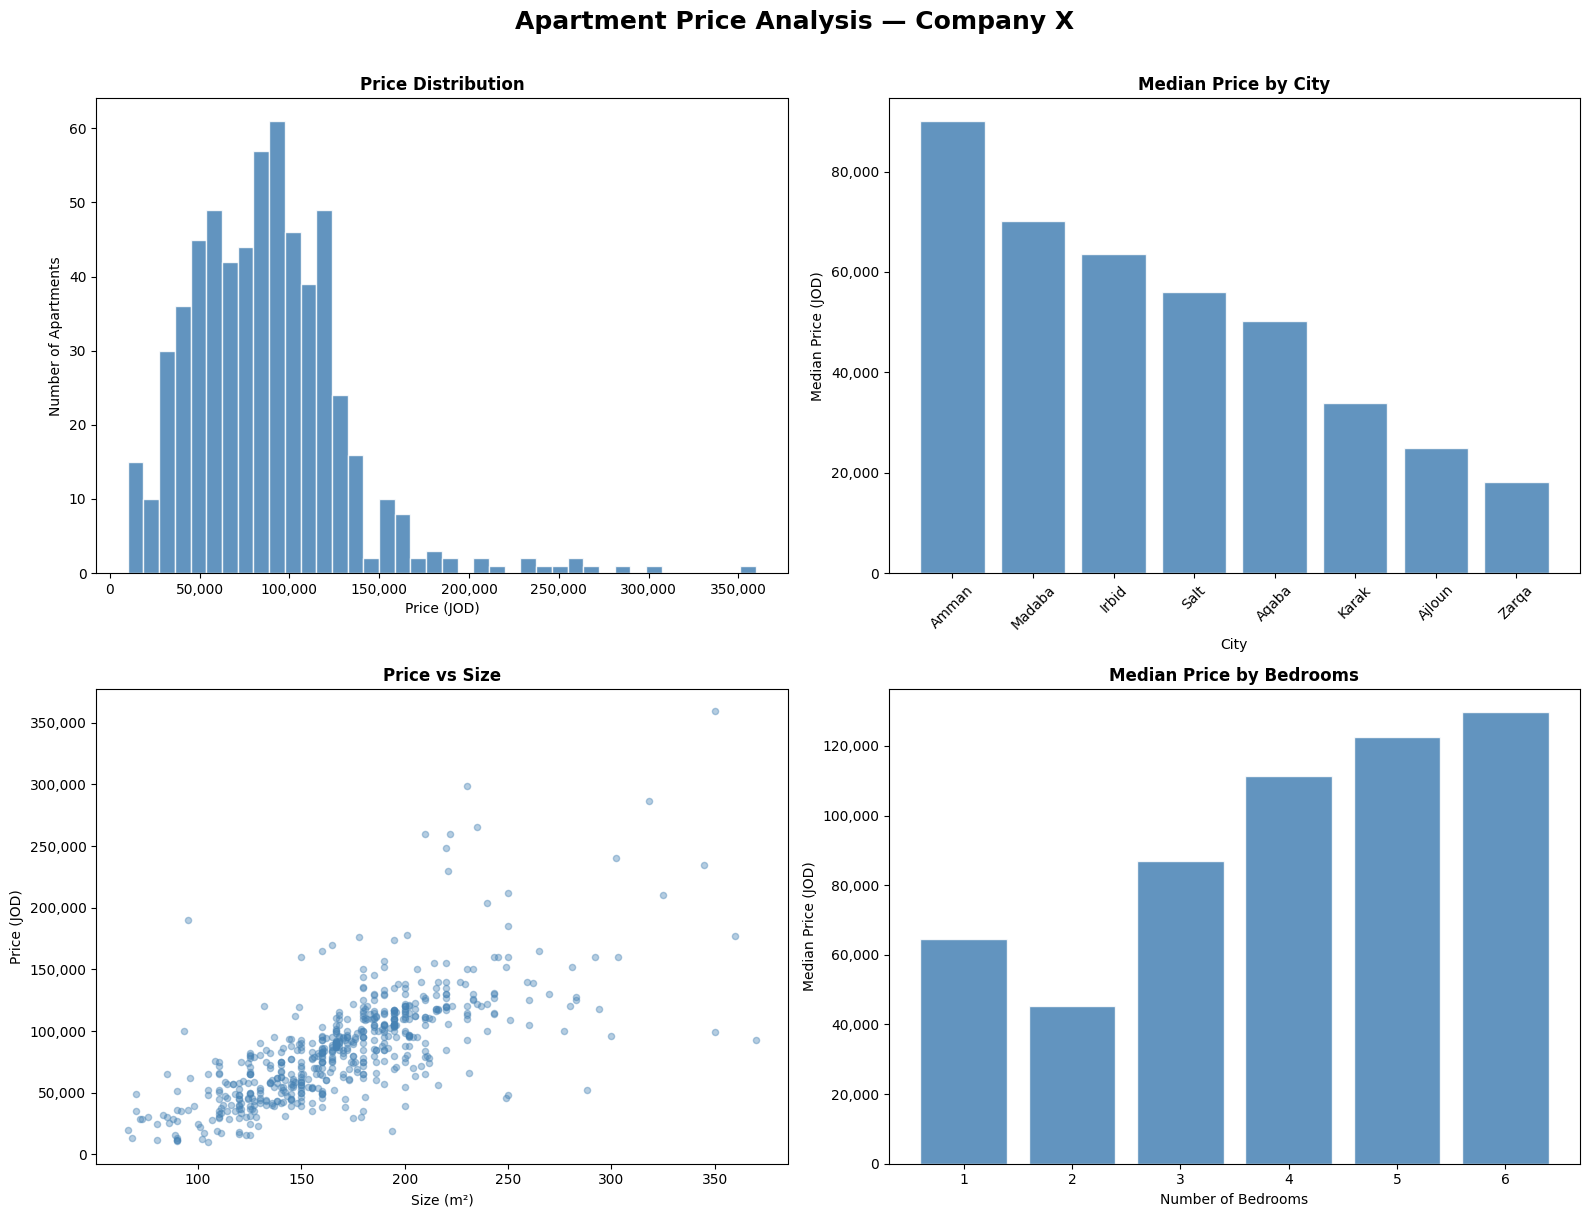

EDA charts saved: eda_charts.png


In [9]:
# -----------------------------------------------------------------------------
# SECTION 6 | EXPLORATORY DATA ANALYSIS (EDA)
# -----------------------------------------------------------------------------
# we create charts to understand the data before building the model
# this helps us see patterns, outliers, and relationships between features

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Apartment Price Analysis — Company X',
             fontsize=18, fontweight='bold', y=1.01)

# -----------------------------------------------------------------------------
# CHART 1 — price distribution
# shows how apartment prices are spread
# are most apartments cheap, expensive, or in the middle?
axes[0,0].hist(df['price'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Price Distribution', fontweight='bold')
axes[0,0].set_xlabel('Price (JOD)')
axes[0,0].set_ylabel('Number of Apartments')
axes[0,0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# -----------------------------------------------------------------------------
# CHART 2 — average price by city
# shows which cities have the most expensive apartments
city_avg = df.groupby('city')['price'].median().sort_values(ascending=False)
axes[0,1].bar(city_avg.index, city_avg.values, color='steelblue',
              edgecolor='white', alpha=0.85)
axes[0,1].set_title('Median Price by City', fontweight='bold')
axes[0,1].set_xlabel('City')
axes[0,1].set_ylabel('Median Price (JOD)')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# -----------------------------------------------------------------------------
# CHART 3 — price vs size
# shows the relationship between apartment size and price
# we expect: bigger size = higher price
axes[1,0].scatter(df['size'], df['price'], alpha=0.4, color='steelblue', s=20)
axes[1,0].set_title('Price vs Size', fontweight='bold')
axes[1,0].set_xlabel('Size (m²)')
axes[1,0].set_ylabel('Price (JOD)')
axes[1,0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# -----------------------------------------------------------------------------
# CHART 4 — average price by number of bedrooms
# shows how price changes as bedrooms increase
bed_avg = df.groupby('Bedrooms ')['price'].median()
axes[1,1].bar(bed_avg.index.astype(int), bed_avg.values,
              color='steelblue', edgecolor='white', alpha=0.85)
axes[1,1].set_title('Median Price by Bedrooms', fontweight='bold')
axes[1,1].set_xlabel('Number of Bedrooms')
axes[1,1].set_ylabel('Median Price (JOD)')
axes[1,1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# -----------------------------------------------------------------------------
plt.tight_layout()
plt.savefig('eda_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA charts saved: eda_charts.png")

In [10]:
# -----------------------------------------------------------------------------
# SECTION 7 | ENCODE CATEGORIES & PREPARE FEATURES
# -----------------------------------------------------------------------------

# ML models only understand numbers — not text like "Amman" or "Abdoun"
# LabelEncoder converts each unique city/location name into a unique number
# example: Amman=1, Zarqa=7, Abdoun=5 ...etc

le_city = LabelEncoder()
le_loc  = LabelEncoder()

df['city_enc']     = le_city.fit_transform(df['city'])
df['location_enc'] = le_loc.fit_transform(df['location'])

# -----------------------------------------------------------------------------
# define which columns the model will use to predict price
# we exclude: Apartment_ID (just a label), price (that's what we predict),
#             price_per_sqm (calculated FROM price → would cause data leakage),
#             floor (replaced by floor_number and is_basement)

FEATURES = [
    'Building Age',   # how old is the building
    'floor_number',   # which floor
    'is_basement',    # is it a basement apartment
    'Bedrooms ',      # number of bedrooms
    'Living room',    # number of living rooms
    'Guest room',     # number of guest rooms
    'Bathroom',       # number of bathrooms
    'Kitchen',        # number of kitchens
    'Storage ',       # has storage room
    "Maid's room ",   # has maid's room
    'Terrace',        # has terrace
    'Garden',         # has garden
    'Roof',           # has roof access
    'Duplex',         # is it a duplex
    'Balcony',        # has balcony
    'size',           # total area in m²
    'furnished',      # is it furnished
    'furnishing_level(1-5)',  # furnishing quality 0-5
    'total_rooms',    # total number of rooms (engineered)
    'amenities_score',# total extra features (engineered)
    'city_enc',       # city as a number
    'location_enc',   # location as a number
]

TARGET = 'price'  # what we want to predict

X = df[FEATURES]
y = df[TARGET]

# -----------------------------------------------------------------------------
# split data into training set and testing set
# training set (80%) → model learns from this
# testing set  (20%) → we use this to check how good the model is
# random_state=42 → ensures we get the same split every time we run the code

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------------------------------------------------------

print(" DATA READY FOR MODELING")
print(f"  Total features   : {len(FEATURES)}")
print(f"  Training set     : {len(X_train)} apartments (80%)")
print(f"  Testing set      : {len(X_test)} apartments  (20%)")
print(f"  Target range     : {y.min():,.0f} — {y.max():,.0f} JOD")


 DATA READY FOR MODELING
  Total features   : 22
  Training set     : 482 apartments (80%)
  Testing set      : 121 apartments  (20%)
  Target range     : 9,975 — 359,800 JOD


In [11]:
# -----------------------------------------------------------------------------
# SECTION 8 | TRAIN AND COMPARE MODELS
# -----------------------------------------------------------------------------

# we train 5 different models and compare their performance
# to find which one predicts apartment prices most accurately

# metrics we use to evaluate each model:
# MAE  (Mean Absolute Error)       → average error in JOD — lower is better
# RMSE (Root Mean Squared Error)   → penalizes big errors more — lower is better
# R²   (R-squared)                 → % of price variation explained — higher is better

models = {
    # fits a straight line through the data — simple but limited
    'Linear Regression': LinearRegression(),

    # like linear regression but adds a penalty to prevent overfitting
    'Ridge Regression':  Ridge(alpha=10),

    # like ridge but can completely ignore useless features
    'Lasso Regression':  Lasso(alpha=100),

    # splits data into branches like a flowchart of yes/no questions
    'Decision Tree':     DecisionTreeRegressor(max_depth=8, random_state=42),

    # builds 200 decision trees and averages their predictions
    # more trees = more accurate and stable
    'Random Forest':     RandomForestRegressor(n_estimators=200, max_depth=12,
                                               min_samples_leaf=3, random_state=42),

    # builds trees one by one — each tree fixes the errors of the previous one
    # usually the most accurate model for structured data
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                    learning_rate=0.05, random_state=42),
}

# -----------------------------------------------------------------------------
results = {}

print("=" * 65)
print(f"  {'Model':<25} {'MAE':>10} {'RMSE':>10} {'R²':>8}")
print("─" * 65)

for name, model in models.items():
    # train the model on training data
    model.fit(X_train, y_train)

    # use the trained model to predict prices on testing data
    preds = model.predict(X_test)

    # calculate performance metrics
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)

    # store results for later use
    results[name] = {
        'model': model,
        'preds': preds,
        'MAE':   mae,
        'RMSE':  rmse,
        'R2':    r2
    }

    # mark the best model
    marker = "BEST" if name == 'Gradient Boosting' else ""
    print(f"  {name:<25} {mae:>10,.0f} {rmse:>10,.0f} {r2:>8.4f}{marker}")

print("=" * 65)

  Model                            MAE       RMSE       R²
─────────────────────────────────────────────────────────────────
  Linear Regression             21,129     34,391   0.4995
  Ridge Regression              20,748     33,334   0.5298
  Lasso Regression              20,791     33,736   0.5184
  Decision Tree                 20,586     37,739   0.3973
  Random Forest                 17,198     28,779   0.6495
  Gradient Boosting             15,193     25,472   0.7254BEST


In [12]:
# -----------------------------------------------------------------------------
# SECTION 9 | EVALUATE BEST MODEL — GRADIENT BOOSTING
# -----------------------------------------------------------------------------

# select the best model based on highest R² score
best_model = results['Gradient Boosting']['model']
y_pred     = results['Gradient Boosting']['preds']

# -----------------------------------------------------------------------------
# cross validation — tests the model on 5 different splits of the data
# this proves the model is reliable, not just lucky on one split
# if all 5 scores are close to each other → model is stable and trustworthy

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_model, X, y, cv=kf, scoring='r2')

# -----------------------------------------------------------------------------
print("=" * 60)
print(" BEST MODEL: GRADIENT BOOSTING")
print("=" * 60)
print(f"  R²   = {results['Gradient Boosting']['R2']:.4f}")
print(f"  MAE  = {results['Gradient Boosting']['MAE']:,.0f} JOD")
print(f"  RMSE = {results['Gradient Boosting']['RMSE']:,.0f} JOD")
print("─" * 60)
print("  Cross Validation (5-Fold):")
for i, score in enumerate(cv_scores, 1):
    bar = '' * int(score * 30)
    print(f"    Fold {i}: R² = {score:.4f}  {bar}")
print(f"\n    Average : {cv_scores.mean():.4f}")
print(f"    Std Dev : {cv_scores.std():.4f}  (lower = more stable)")
print("=" * 60)

 BEST MODEL: GRADIENT BOOSTING
  R²   = 0.7254
  MAE  = 15,193 JOD
  RMSE = 25,472 JOD
────────────────────────────────────────────────────────────
  Cross Validation (5-Fold):
    Fold 1: R² = 0.7224  
    Fold 2: R² = 0.7632  
    Fold 3: R² = 0.5876  
    Fold 4: R² = 0.5371  
    Fold 5: R² = 0.6257  

    Average : 0.6472
    Std Dev : 0.0840  (lower = more stable)


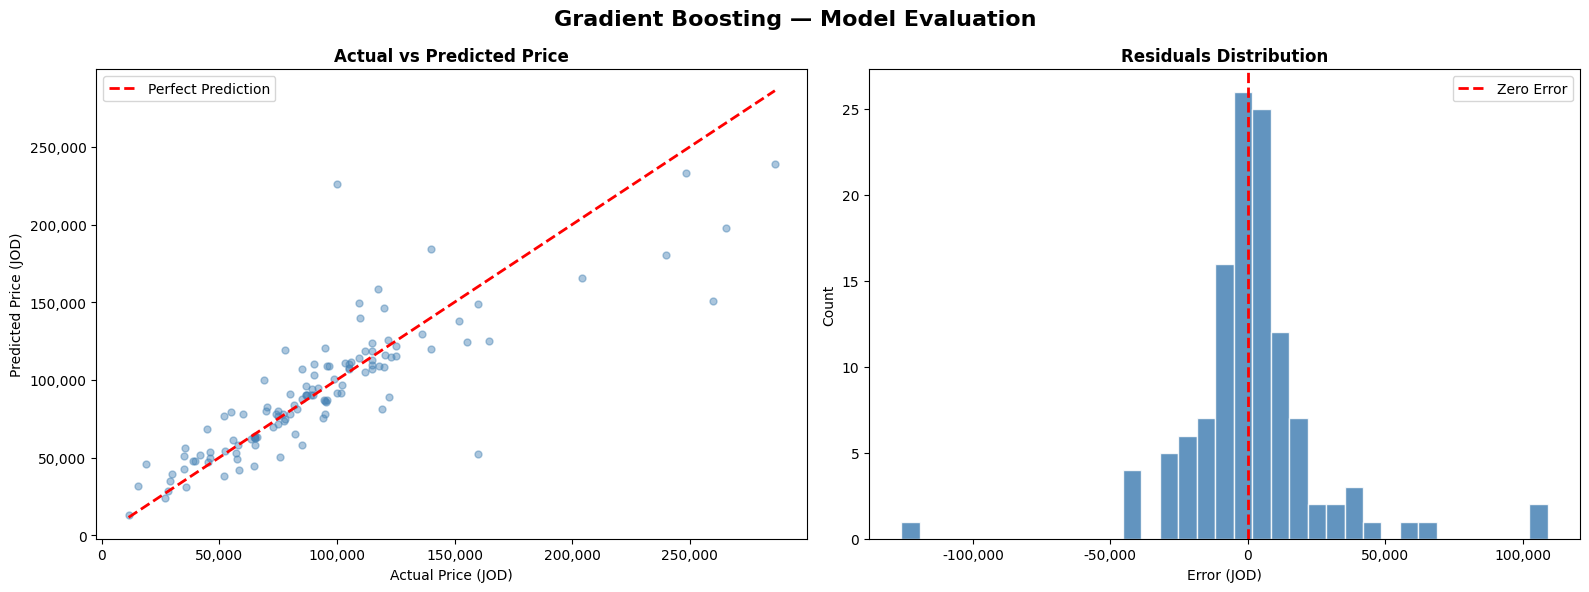

Chart saved: model_evaluation.png


In [13]:
# -----------------------------------------------------------------------------
# SECTION 10 | EVALUATION CHARTS
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Gradient Boosting — Model Evaluation',
             fontsize=16, fontweight='bold')

# -----------------------------------------------------------------------------
# CHART 1 — Actual vs Predicted
# each dot = one apartment
# x axis = real price, y axis = predicted price
# if the model is perfect → all dots fall on the red dashed line
# dots far from the line = big prediction errors

axes[0].scatter(y_test, y_pred, alpha=0.45, color='steelblue', s=25)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect Prediction')
axes[0].set_title('Actual vs Predicted Price', fontweight='bold')
axes[0].set_xlabel('Actual Price (JOD)')
axes[0].set_ylabel('Predicted Price (JOD)')
axes[0].legend()
axes[0].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# -----------------------------------------------------------------------------
# CHART 2 — Residuals (Errors)
# residual = actual price minus predicted price
# if residuals are centered around 0 → model has no consistent bias
# a bell shape around 0 = good model

residuals = y_test.values - y_pred
axes[1].hist(residuals, bins=35, color='steelblue', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero Error')
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Error (JOD)')
axes[1].set_ylabel('Count')
axes[1].legend()
axes[1].xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# -----------------------------------------------------------------------------
plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved: model_evaluation.png")

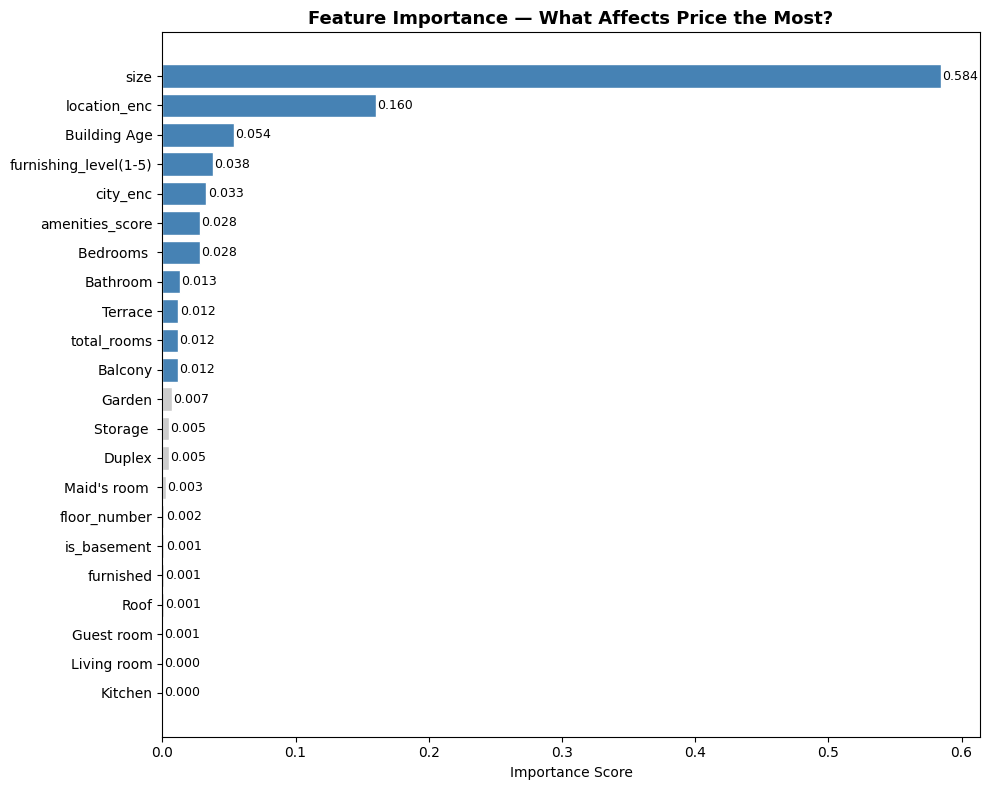

  TOP 5 MOST IMPORTANT FEATURES
  size                      0.5845                                                            
  location_enc              0.1603                  
  Building Age              0.0537       
  furnishing_level(1-5)     0.0377     
  city_enc                  0.0331     


In [15]:
# -----------------------------------------------------------------------------
# SECTION 11 | FEATURE IMPORTANCE
# -----------------------------------------------------------------------------
# feature importance tells us which features affect the price the most
# the model gives each feature a score between 0 and 1
# higher score = more important for predicting price

importances = pd.Series(
    best_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 8))

# color the most important features in blue, others in gray
colors = ['steelblue' if v > importances.median() else '#CCCCCC'
          for v in importances.values]

bars = plt.barh(importances.index, importances.values,
                color=colors, edgecolor='white')

# add value labels on each bar
for bar, val in zip(bars, importances.values):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)

plt.title('Feature Importance — What Affects Price the Most?',
          fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# print top 5 most important features
print("=" * 60)
print("  TOP 5 MOST IMPORTANT FEATURES")
print("=" * 60)
top5 = importances.sort_values(ascending=False).head(5)
for feat, imp in top5.items():
    bar =  " " * int(imp * 100)
    print(f"  {feat:<25} {imp:.4f}  {bar}")
print("=" * 60)

In [17]:
# -----------------------------------------------------------------------------
# SECTION 12 | PREDICT NEW APARTMENT PRICE
# -----------------------------------------------------------------------------
# this function takes apartment details and returns the predicted price
# anyone can use this function to estimate the price of any apartment

def predict_price(city, location, size, bedrooms, bathrooms,
                  building_age, floor_num,
                  furnished=0, furnishing_level=0,
                  living_room=1, guest_room=1, kitchen=1,
                  storage=0, maids_room=0, terrace=0,
                  garden=0, roof=0, duplex=0, balcony=1):

    # convert city name to number — must match training data format
    city_norm = city.strip().title()
    loc_norm  = location.strip().title()

    city_enc = le_city.transform([city_norm])[0] if city_norm in le_city.classes_ else 0
    loc_enc  = le_loc.transform([loc_norm])[0]   if loc_norm  in le_loc.classes_  else 0

    # calculate engineered features
    is_basement    = 1 if floor_num == 0 else 0
    total_rooms    = bedrooms + living_room + guest_room + bathrooms + kitchen
    amenities      = storage + maids_room + terrace + garden + roof + duplex + balcony

    # build input row — same format as training data
    input_data = pd.DataFrame([{
        'Building Age':          building_age,
        'floor_number':          floor_num,
        'is_basement':           is_basement,
        'Bedrooms ':             bedrooms,
        'Living room':           living_room,
        'Guest room':            guest_room,
        'Bathroom':              bathrooms,
        'Kitchen':               kitchen,
        'Storage ':              storage,
        "Maid's room ":          maids_room,
        'Terrace':               terrace,
        'Garden':                garden,
        'Roof':                  roof,
        'Duplex':                duplex,
        'Balcony':               balcony,
        'size':                  size,
        'furnished':             furnished,
        'furnishing_level(1-5)': furnishing_level,
        'total_rooms':           total_rooms,
        'amenities_score':       amenities,
        'city_enc':              city_enc,
        'location_enc':          loc_enc,
    }])

    # predict price using the trained model
    price = best_model.predict(input_data[FEATURES])[0]
    price = round(price, -2)   # round to nearest 100 JOD

    # -----------------------------------------------------------------------------
    print("=" * 60)
    print("   APARTMENT PRICE PREDICTION")
    print("=" * 60)
    print(f"  City          : {city_norm}")
    print(f"  Location      : {loc_norm}")
    print(f"  Size          : {size} m²")
    print(f"  Bedrooms      : {bedrooms}")
    print(f"  Bathrooms     : {bathrooms}")
    print(f"  Building Age  : {building_age} years")
    print(f"  Floor         : {'Basement' if floor_num == 0 else floor_num}")
    print("─" * 60)
    print(f"  Predicted Price : {price:,.0f} JOD")
    print(f"  Price per m²    : {price/size:,.0f} JOD/m²")
    print("=" * 60)

    return price

# -----------------------------------------------------------------------------
# example — apartment in Abdoun, Amman
predict_price(
    city           = 'Amman',
    location       = 'Abdoun',
    size           = 200,
    bedrooms       = 3,
    bathrooms      = 2,
    building_age   = 3,
    floor_num      = 2,
    balcony        = 1,
    furnished      = 0,
    furnishing_level = 0,
)

   APARTMENT PRICE PREDICTION
  City          : Amman
  Location      : Abdoun
  Size          : 200 m²
  Bedrooms      : 3
  Bathrooms     : 2
  Building Age  : 3 years
  Floor         : 2
────────────────────────────────────────────────────────────
  Predicted Price : 178,800 JOD
  Price per m²    : 894 JOD/m²


np.float64(178800.0)

In [22]:
# -----------------------------------------------------------------------------
# SECTION 13 | SAVE MODEL & EXPORT DATA FOR TABLEAU
# -----------------------------------------------------------------------------

# ── SAVE MODEL ────────────────────────────────────────────────────────────────
# save the trained model so we can use it later without retraining
# joblib.dump() → saves the object to a file
# joblib.load() → loads it back when needed

joblib.dump(best_model, 'best_model.pkl')
joblib.dump(le_city,    'le_city.pkl')
joblib.dump(le_loc,     'le_loc.pkl')

# ── EXPORT FOR TABLEAU ────────────────────────────────────────────────────────
# add predictions and analysis columns to the full dataset
# this file will be used to build the Tableau dashboard

df['predicted_price'] = best_model.predict(X)

# error = difference between actual and predicted price
df['error']     = df['price'] - df['predicted_price']

# error percentage = how far off was the prediction in %
df['error_pct'] = (df['error'] / df['price'] * 100).round(2)

# price range category — useful for grouping in Tableau
df['price_range'] = pd.cut(
    df['price'],
    bins   = [0, 50000, 80000, 120000, 180000, float('inf')],
    labels = ['Under 50K', '50K-80K', '80K-120K', '120K-180K', 'Above 180K']
)

# export to CSV for Tableau
df.to_csv('apartments_tableau.csv', index=False)

# ── SUMMARY ───────────────────────────────────────────────────────────────────
print("=" * 60)
print("   PROJECT COMPLETE")
print("=" * 60)
print("  Saved Files:")
print("  best_model.pkl        → trained ML model")
print("  le_city.pkl           → city encoder")
print("  le_loc.pkl            → location encoder")
print("  apartments_tableau.csv → data for Tableau")
print("─" * 60)
print("  Model Performance:")
print(f"    R²   = {results['Gradient Boosting']['R2']:.4f}")
print(f"    MAE  = {results['Gradient Boosting']['MAE']:,.0f} JOD")
print(f"    RMSE = {results['Gradient Boosting']['RMSE']:,.0f} JOD")
print("─" * 60)
print("  Top 3 Price Factors:")
print("    1. Size (m²)       → 58%")
print("    2. Location        → 16%")
print("    3. Building Age    →  5%")
print("=" * 60)

   PROJECT COMPLETE
  Saved Files:
  best_model.pkl        → trained ML model
  le_city.pkl           → city encoder
  le_loc.pkl            → location encoder
  apartments_tableau.csv → data for Tableau
────────────────────────────────────────────────────────────
  Model Performance:
    R²   = 0.7254
    MAE  = 15,193 JOD
    RMSE = 25,472 JOD
────────────────────────────────────────────────────────────
  Top 3 Price Factors:
    1. Size (m²)       → 58%
    2. Location        → 16%
    3. Building Age    →  5%
